## LAB 06 CZYSZCZENIE DANYCH 
### Ocena efektów- skuteczność klasyfikacji
Funkcja score_dataset zwraca średnią z wartości bezwzględnej błędu dla zbioru testowego.

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np


def score_dataset(x_train, x_valid, y_train, y_valid):
    model = RandomForestRegressor(n_estimators=100, random_state=0)
    model.fit(x_train, y_train)
    preds = model.predict(x_valid)
    return mean_absolute_error(y_valid, preds)

W zadaniach będziemy posługiwać się zbiorem opisującym historię sprzedaży budynków, zawierającym szczegóły dotyczące nieruchomości oraz cenę za jaką zostały sprzedane: melb_data.csv.

In [49]:
# Wczytanie danych
df = pd.read_csv('dataset/melb_data.csv')

# Podział na zbiór treningowy i testowy
train_df, test_df = train_test_split(df, test_size=0.3)

# Sprawdzenie brakujących wartości
missing_values_count = df.isnull().sum()

# Określ dla każdej kolumny procent występowania wartości brakujących
missing_values_percent = (df.isnull().sum() / len(df)) * 100

# Połącz w DataFrame używając pd.concat
missing_data = pd.concat([missing_values_count, missing_values_percent], axis=1, keys=['count', 'percent'])

print(missing_data)

               count    percent
Suburb             0   0.000000
Address            0   0.000000
Rooms              0   0.000000
Type               0   0.000000
Price              0   0.000000
Method             0   0.000000
SellerG            0   0.000000
Date               0   0.000000
Distance           0   0.000000
Postcode           0   0.000000
Bedroom2           0   0.000000
Bathroom           0   0.000000
Car               62   0.456554
Landsize           0   0.000000
BuildingArea    6450  47.496318
YearBuilt       5375  39.580265
CouncilArea     1369  10.081001
Lattitude          0   0.000000
Longtitude         0   0.000000
Regionname         0   0.000000
Propertycount      0   0.000000


Jak widać powyżej w datasecie są elementy brakujące. Istnieje kilka podejść na pozbycie się elementów brakujących. 

### Podejście 1: usunięcie kolumn/wierszy zawierających przynajmniej 1 element pusty

In [ ]:
df_cleaned_rows = train_df.dropna()
# Sprawdź które wiersze zostały usunięte
removed_rows = train_df.index.difference(df_cleaned_rows.index)
# Usuń tylko wiersze w których wartości puste są w kolumnie BuildingArea i YearBuilt
df_cleaned_building_area = train_df.dropna(subset=['BuildingArea'])
# Usuń tylko wiersze w których wartości puste są jednocześnie w kolumnie BuildingArea i YearBuilt
train_df_cleaned = train_df.dropna(subset=['BuildingArea', 'YearBuilt'], how='all')
# Sprawdź ile zostało wierszy po usunięciu
print(f"Liczba wierszy po usunięciu: {len(train_df_cleaned)}")
# Oczyść zbiór testowy w ten sam sposób
test_df_cleaned = test_df.dropna(subset=['BuildingArea', 'YearBuilt'], how='all')
# Sprawdź skutecznosć klasyfikacji dla oczyszczonych danych
cols_x = train_df_cleaned.select_dtypes(include=[np.number]).columns.difference(['Price'])  # wybiera tylko kolumny z wartosciami numerycznymi, za wyjątkiem kolumny z wartością referencyjną - wejście do klasyfikatora
cols_y = 'Price'  # - wyjście z klasyfikatora
print(score_dataset(train_df_cleaned[cols_x], test_df_cleaned[cols_x], train_df_cleaned[cols_y], test_df_cleaned[cols_y]))


Liczba wierszy po usunięciu: 5908
168623.9899341786


### Podejście 2: wypełnienie pustych wartości np. zerami lub wartością, która poprzedza wartość brakującą

In [10]:
train_df_cleaned_zeros = train_df.fillna(0) # wypełnia zerami
test_df_cleaned_zeros = test_df.fillna(0) # wypełnia zerami
# Sprawdź skutecznosć klasyfikacji dla oczyszczonych danych
cols_x = train_df_cleaned_zeros.select_dtypes(include=[np.number]).columns.difference(['Price'])  # wybiera tylko kolumny z wartosciami numerycznymi, za wyjątkiem kolumny z wartością referencyjną - wejście do klasyfikatora
cols_y = 'Price'  # - wyjście z klasyfikatora
print(score_dataset(train_df_cleaned_zeros[cols_x], test_df_cleaned_zeros[cols_x], train_df_cleaned_zeros[cols_y], test_df_cleaned_zeros[cols_y]))

train_df_cleaned_bfill = train_df.fillna(method='bfill', axis=0).fillna(0)  # wypełnia wartością następującą z danej kolumny, jeśli to niemożliwe, wstawia 0
test_df_cleaned_bfill = test_df.fillna(method='bfill', axis=0).fillna(0)  # wypełnia wartością następującą z danej kolumny, jeśli to niemożliwe, wstawia 0
# Sprawdź skutecznosć klasyfikacji dla oczyszczonych danych
cols_x = train_df_cleaned_bfill.select_dtypes(include=[np.number]).columns.difference(['Price'])  # wybiera tylko kolumny z wartosciami numerycznymi
cols_y = 'Price'  # - wyjście z klasyfikatora
print(score_dataset(train_df_cleaned_bfill[cols_x], test_df_cleaned_bfill[cols_x], train_df_cleaned_bfill[cols_y], test_df_cleaned_bfill[cols_y]))

171693.95318687614


/tmp/ipykernel_81618/2667880662.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df_cleaned_bfill = train_df.fillna(method='bfill', axis=0).fillna(0)  # wypełnia wartością następującą z danej kolumny, jeśli to niemożliwe, wstawia 0
/tmp/ipykernel_81618/2667880662.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  test_df_cleaned_bfill = test_df.fillna(method='bfill', axis=0).fillna(0)  # wypełnia wartością następującą z danej kolumny, jeśli to niemożliwe, wstawia 0


178427.37932487082


Podejście polegające na wypełnianiu zerami ma sens jeśli dane mają rozkład normalny i ich średnia wynosi 0. Wypełnianie wartością sąsiednią ma sens wtedy gdy zbiór danych jest w pewien sposób uporządkowany (np. chronologicznie). Oprócz wypełniania wartością poprzedzającą z danej kolumny można także użyć wypełnianie wartością następującą (method='bfil')

### Podejście 3: podstawienie wartości średniej/mediany/mody

In [ ]:
from sklearn.impute import SimpleImputer


imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean') 
df_train_numeric = train_df.select_dtypes(include=[np.number]).copy()
df_test_numeric = test_df.select_dtypes(include=[np.number]).copy()#wybór tylko kolumn przechowujacych liczby, należy wykonać kopię obiektu

df_train_numeric.loc[:] = imp_mean.fit_transform(df_train_numeric)  # dopasowanie parametrów (średnich) i transformacja zbioru uczącego
df_test_numeric[:]  = imp_mean.transform(df_test_numeric)  # zastosowanie modelu do transformacji zbioru testowego (bez wyznaczania parametrów)

# Sprawdź skutecznosć klasyfikacji dla oczyszczonych danych
cols_x = df_train_numeric.select_dtypes(include=[np.number]).columns.difference(['Price'])
cols_y = 'Price'  # - wyjście z klasyfikatora
print(score_dataset(df_train_numeric[cols_x], df_test_numeric[cols_x], train_df[cols_y], test_df[cols_y]))


172751.57995470698


Wypełnianie wartością średną ma sens kiedy dane mają rozkład normalny i nie ma wartości odstających, a wypełnianie medianą ma sens dla wartości dyskretnych. Do brakujących wartości referencyjnych zastosowałbym medianę, a do brakujących cech zastosowałbym średnią. 

Na podstawie wyników klasyfikacji dla wszystkich przedstawionych podejść widać że usuwanie wierszy jest najbardziej skuteczne.

## Konwersja danych

Konwersja dat i czasów

In [29]:
print(df.loc[23, "Date"])
# Date format to DD/MM/YYYY

df.loc[:, "Datetime"] = pd.to_datetime(df.loc[:, "Date"], format="%d/%m/%Y")

18/06/2016


Wyznaczanie zakresów dat i interwałów

In [32]:
year_2017 = pd.Interval(pd.Timestamp('2017-01-01 00:00:00'), pd.Timestamp('2018-01-01 00:00:00'), closed='left')

Wyznaczanie dnia tygodnia

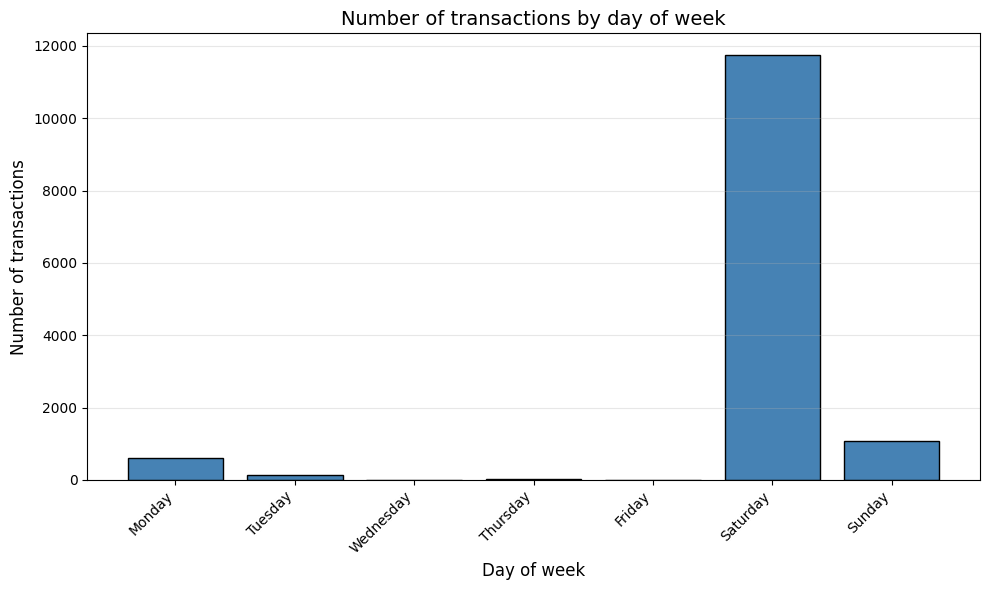

In [38]:
df.loc[:, "Day of week"] = df.loc[:, "Datetime"].dt.dayofweek

# Wykreśl histogram liczby dokonanych transakcji w zależności od dnia tygodnia.
from matplotlib import pyplot as plt
# Zlicz transakcje dla każdego dnia tygodnia i uzupełnij brakujące dni zerami
day_counts = df["Day of week"].value_counts().reindex(range(7), fill_value=0)

# Nazwy dni tygodnia
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(day_names, day_counts.values, color='steelblue', edgecolor='black')
ax.set_xlabel('Day of week', fontsize=12)
ax.set_ylabel('Number of transactions', fontsize=12)
ax.set_title('Number of transactions by day of week', fontsize=14)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Zmienne nominalne

In [41]:
df.loc[:, "RegionName"] = df.loc[:, "Regionname"].astype("category")
print(df["RegionName"])

0             Northern Metropolitan
1             Northern Metropolitan
2             Northern Metropolitan
3             Northern Metropolitan
4             Northern Metropolitan
                    ...            
13575    South-Eastern Metropolitan
13576          Western Metropolitan
13577          Western Metropolitan
13578          Western Metropolitan
13579          Western Metropolitan
Name: RegionName, Length: 13580, dtype: category
Categories (8, object): ['Eastern Metropolitan', 'Eastern Victoria', 'Northern Metropolitan', 'Northern Victoria', 'South-Eastern Metropolitan', 'Southern Metropolitan', 'Western Metropolitan', 'Western Victoria']


Łączenie zmiennych nominalnych

In [43]:
num_unique = np.unique(df["Suburb"])
print(f"Liczba unikalnych wartości w kolumnie 'Suburb': {len(num_unique)}")
# zmiana na małe litery
df['Suburb'] = df['Suburb'].str.lower()
num_unique_after = np.unique(df["Suburb"])
print(f"Liczba unikalnych wartości w kolumnie 'Suburb' po zmianie na małe litery: {len(num_unique_after)}")
# usunięcie końcowych spacji
df['Suburb'] = df['Suburb'].str.strip()
num_unique_after_strip = np.unique(df["Suburb"])
print(f"Liczba unikalnych wartości w kolumnie 'Suburb' po usunięciu końcowych spacji: {len(num_unique_after_strip)}")

Liczba unikalnych wartości w kolumnie 'Suburb': 314
Liczba unikalnych wartości w kolumnie 'Suburb' po zmianie na małe litery: 314
Liczba unikalnych wartości w kolumnie 'Suburb' po usunięciu końcowych spacji: 314


In [47]:
import fuzzywuzzy.process


def replace_matches_in_column(df, column, string_to_match, min_ratio = 90):
    # get a list of unique strings
    strings = df[column].unique()
    
    # get the top 10 closest matches to our input string
    matches = fuzzywuzzy.process.extract(string_to_match, strings, 
                                         limit=10, scorer=fuzzywuzzy.fuzz.token_sort_ratio)

    # only get matches with a ratio > 90
    close_matches = [matches[0] for matches in matches if matches[1] >= min_ratio]

    # get the rows of all the close matches in our dataframe
    rows_with_matches = df[column].isin(close_matches)

    # replace all rows with close matches with the input matches 
    df.loc[rows_with_matches, column] = string_to_match

/home/gwidon/anaconda3/envs/eda_env/lib/python3.13/site-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [48]:
# Wczytaj zbiór danych w którym zostały wprowadzone typowe pomyłki w niekrórych kolumnach
df = pd.read_csv('dataset/melb_data_distorted.csv')
num_unique = np.unique(df["Suburb"])
print(f"Liczba unikalnych wartości w kolumnie 'Suburb': {len(num_unique)}")
df['Suburb']= df['Suburb'].str.lower().str.strip()

# Pobierz wszystkie unikalne wartości po normalizacji
unique_suburbs = df['Suburb'].unique()

# Dla każdej unikalnej wartości zastosuj fuzzy matching
for suburb in unique_suburbs:
    replace_matches_in_column(df, 'Suburb', suburb, min_ratio=90)

num_unique_after_fuzzy = np.unique(df["Suburb"])
print(f"Liczba unikalnych wartości w kolumnie 'Suburb' po fuzzy matching: {len(num_unique_after_fuzzy)}")

Liczba unikalnych wartości w kolumnie 'Suburb': 1321
Liczba unikalnych wartości w kolumnie 'Suburb' po fuzzy matching: 681


Jeśli minimalny próg podobieństwa ustalimy na 90% to zostanie o połowę mniej unikalnych elementów

Konwersja zmienna porządkowa → wartości liczbowe

In [50]:
from sklearn.preprocessing import LabelEncoder


# Make copy to avoid changing original data 
label_train = train_df.copy()
label_test = test_df.copy()

# Apply label encoder to each column with categorical data
label_encoder = LabelEncoder()
col='CouncilArea'
label_train[col] = label_encoder.fit_transform(label_train[col])
label_test[col] = label_encoder.transform(label_test[col])

Podejście z wykorzystaniem Label Encoder sprawdzi się w przypadku kategorii o określonej strukturze np. w przypadku zmiennej nominalnej siła wiatru. Sprawdzie się również w przypadku wykorzystania algorytum Random Tree oraz Random Forrest które są niewrażliwe na hierarchiczną kolejność

Zmienna nominalna- enkoder binarny

In [53]:
from sklearn.preprocessing import LabelBinarizer


# Make copy to avoid changing original data 
label_train = train_df.copy()
label_test = test_df.copy()

label_binarizer = LabelBinarizer()

col = 'CouncilArea'
# Wypełnienie brakujących wartości przed enkodowaniem
label_train[col] = label_train[col].fillna('Unknown')
label_test[col] = label_test[col].fillna('Unknown')

lb_results = label_binarizer.fit_transform(label_train[col])
lb_results_df = pd.DataFrame(lb_results, columns=label_binarizer.classes_)

Rozwiązanie to nie sprawdzi się w predyktorze ceny na podstawie nazw obszarów administracyjnych dlatego że jest bardzo dużo kategorii obszarów, natomiast jest odpowiednie w predyktorze na podstawie dnia tygodnia, dlatego że eliminuje hierarchiczność poszczególnych dni. Rozwiązanie to nie sprawdzi się do klasyfikacji zmiennej nominalnej siła wiatru jeżeli chcielibyśmy zachować hierarchiczność. 